In [68]:
# With Encodings Setup scale pos 1/2.5
import lightgbm as lgb
import pandas as pd
import  numpy as np
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# For preprocessing function

In [ ]:
import datetime
import re
import pandas as pd
LOG_FILE = "logger.txt"
def summarize_experiment_logs(log_file=LOG_FILE, sort_by_roc=True, top_n=None):
    """
    Summarize experiments from a logger.txt file.
    
    Args:
        log_file (str): Path to the log file.
        sort_by_roc (bool): Whether to sort by ROC-AUC descending.
        top_n (int or None): If specified, return only the top N experiments.
    
    Returns:
        pd.DataFrame: DataFrame with Timestamp and ROC-AUC Score.
    """
    timestamps = []
    roc_scores = []

    with open(log_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        # Capture timestamp
        if line.startswith("Timestamp:"):
            ts = line.split("Timestamp:")[1].strip()
            timestamps.append(ts)
        # Capture ROC-AUC score
        elif line.startswith("ROC AUC Score:"):
            match = re.findall(r"[\d\.]+", line)
            if match:
                roc_scores.append(float(match[0]))

    # Make DataFrame
    df = pd.DataFrame({
        "Timestamp": timestamps,
        "ROC-AUC Score": roc_scores
    })

    if sort_by_roc:
        df = df.sort_values("ROC-AUC Score", ascending=False).reset_index(drop=True)

    if top_n is not None:
        df = df.head(top_n)

    return df


n_splits = 5

def format_confusion_matrix(cm, labels=None):
    """
    Returns a list of strings representing a nicely formatted confusion matrix.
    """
    if labels is None:
        labels = [str(i) for i in range(cm.shape[0])]
    
    text = []
    # Header
    header = " " * 10 + "".join([f"{lbl:>10}" for lbl in labels])
    text.append(header)
    text.append("-" * (10 + 10*len(labels)))
    
    # Rows
    for i, row in enumerate(cm):
        row_str = f"{labels[i]:<10}" + "".join([f"{int(round(v)):>10}" for v in row])
        text.append(row_str)
    
    return text


def log_experiment_pretty(
    model,
    roc_score,
    avg_report,
    features_used=None,
    conf_mat=None,
    notes=None,
):

    # ---- Params ----
    params = model.get_params()

    # ---- Feature importance ----
    try:
        importances = model.feature_importances_
    except:
        importances = None

    # ---- Build the text block ----
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    text = []
    text.append("=" * 25 + " EXPERIMENT LOG " + "=" * 25)
    text.append(f"Timestamp: {timestamp}\n")
    text.append(f"ROC AUC Score: {roc_score:.5f}\n", )

    # --- Model parameters ---
    text.append("Model Parameters:")
    for k, v in params.items():
        text.append(f"    {k}: {v}")
    text.append("")

    # --- Features used ---
    if features_used:
        text.append(f"Features Used ({len(features_used)}):")
        text.append("    " + ", ".join(features_used))
        text.append("")

    # --- Feature importance ---
    if features_used and importances is not None:
        text.append("Feature Importances:")
        for feat, imp in zip(features_used, importances):
            text.append(f"    {feat}: {float(imp)}")
        text.append("")

    # --- ROC-AUC ---
    text.append(f"ROC-AUC Score: {roc_score}\n")

    # --- Cross-validation report ---
    text.append(f"=== {n_splits}-Fold Cross-Validation Classification Report (Averaged) ===\n")

    # Header
    header = f"{'Class':<10}{'Precision':>10}{'Recall':>10}{'F1-Score':>10}{'Support':>10}"
    text.append(header)
    text.append("-"*50)

    for label, metrics in avg_report.items():
        # Skip non-dict entries like 'accuracy'
        if not isinstance(metrics, dict):
            continue
        
        precision = metrics.get('precision', 0.0)
        recall = metrics.get('recall', 0.0)
        f1 = metrics.get('f1-score', 0.0)
        support = int(metrics.get('support', 0))
        
        line = f"{str(label):<10}{precision:>10.2f}{recall:>10.2f}{f1:>10.2f}{support:>10}"
        text.append(line)

    # Add accuracy separately if exists
    if 'accuracy' in avg_report:
        acc = avg_report['accuracy']
        text.append("-"*50)
        text.append(f"{'Accuracy':<10}{acc:>10.4f}")

    text.append("")


    # Confusion Matric Usage:
    avg_cm_text = format_confusion_matrix(conf_mat)
    text.append("=== Average Confusion Matrix (over CV folds) ===")
    text.extend(avg_cm_text)
    text.append("")  # blank line after

    # --- Additional notes ---
    if notes:
        text.append("Notes:")
        text.append(f"    {notes}\n")

    text.append("-" * 55 + "\n")

    # ---- Append to file ----
    with open(LOG_FILE, "a") as f:
        f.write("\n".join(text))

    print("✔ Logged experiment in readable format to logger.txt")


In [2]:
numeric_cols = [
    'log_income_loan_dti', 'grade_num', 
    'annual_income', 'debt_to_income_ratio',
    'interest_rate', 'credit_score',
    'grade_dti_loan', 'grade_num_dti',
    'loan_amount'
]

category_cols = [
    'gender', 'marital_status',
    'education_level', 'employment_status',
    'loan_purpose', 'grade_subgrade'      
]

In [4]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

In [89]:
train_org = pd.read_csv(r"../playground-series-s5e11/train.csv")
test = pd.read_csv(r"../playground-series-s5e11/test.csv")

train_grade = train_org['grade_subgrade'].sort_values().unique().tolist()
test_grade = test['grade_subgrade'].sort_values().unique().tolist()

grade_order = sorted(list(set(test_grade + train_grade)))

grade_subgrade_map = {grade: i+1 for i, grade in enumerate(grade_order)}
grade_subgrade_map

{'A1': 1,
 'A2': 2,
 'A3': 3,
 'A4': 4,
 'A5': 5,
 'B1': 6,
 'B2': 7,
 'B3': 8,
 'B4': 9,
 'B5': 10,
 'C1': 11,
 'C2': 12,
 'C3': 13,
 'C4': 14,
 'C5': 15,
 'D1': 16,
 'D2': 17,
 'D3': 18,
 'D4': 19,
 'D5': 20,
 'E1': 21,
 'E2': 22,
 'E3': 23,
 'E4': 24,
 'E5': 25,
 'F1': 26,
 'F2': 27,
 'F3': 28,
 'F4': 29,
 'F5': 30}

In [53]:
def preprocessing_new_findings(data):
    data = data.copy()

    # Map grade_subgrade to numeric
    data['grade_num'] = data.grade_subgrade.map(grade_subgrade_map)
    # data = data.drop(columns="grade_subgrade")
    # Grade DTI interaction.
    data['grade_num_dti'] = data.grade_num * data.debt_to_income_ratio

    data['grade_dti_loan'] =  data.grade_num * data.debt_to_income_ratio * np.log10(data.loan_amount)
    data['gr_ln_dti_ir_cs'] = np.log10(data.grade_num) * np.log10(data.loan_amount) * data.debt_to_income_ratio * data.interest_rate * np.log10(data.credit_score)

    # data["grade_emp"] = (data["grade_subgrade"] + "_" + data["employment_status"])
    data["grade_purpose"] = (data["grade_subgrade"] + "_" + data["loan_purpose"])
    # data["grade_edu"] = (data["grade_subgrade"] + "_" + data["education_level"])
    # data["grade_marital"] = (data["grade_subgrade"] + "_" + data["marital_status"])
    # data["grade_gender"] = (data["grade_subgrade"] + "_" + data["gender"])
    # addcols = ["grade_emp", "grade_purpose", "grade_edu", "grade_marital", "grade_gender"]


    # # Chatgpt Features
    # data["dti_per_k"] = data["debt_to_income_ratio"] * (data["loan_amount"] / 1000)
    # data["income_stress"] = data["loan_amount"] / (data["annual_income"] + 1)
    # data["income_stress_adj"] = data["income_stress"] * data["interest_rate"]


    # # Chatgpt Intrest
    # data["interest_per_k"] = data["interest_rate"] * (data["loan_amount"] / 1000)
    # data["interest_income_ratio"] = data["interest_rate"] / np.log1p(data["annual_income"])
    # data["affordability"] = data["annual_income"] / (data["loan_amount"] * data["interest_rate"] + 1)


    # data = pd.get_dummies(data=data, columns=category_cols + ['grade_purpose'], drop_first=True)
    data[category_cols + ['grade_purpose']] = data[category_cols + ['grade_purpose']].astype("category")

    # Create combined metric feature
    data["log_income_loan_dti"] = (
        np.log10(data['annual_income']) *
        np.log10(data['loan_amount']) *
        data["debt_to_income_ratio"]
    )
    # data[category_cols] = data[category_cols].astype('category')
    return data

In [96]:
def preprocessed_pipe(add_cols=[], to_encoding=False, drop_original=True, keep=[]):
    processed_df = preprocessing_new_findings(data=train_org.copy())
    processed_test = preprocessing_new_findings(test.copy())

    # 🧩 Step 1: Split data
    X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
    X = X.drop('id', axis=1)  # replace with your target column
    y = processed_df['loan_paid_back']

    X_res_org = processed_test.drop('id', axis=1)  # Assuming test set doesn't have target
    # X_res[test_cols] = X[test_cols].astype('float64')
    X_res = X_res_org.copy()
    X_id = processed_test['id']

    keep_cols = X[keep], X_res[keep]

    if to_encoding:
        encoder = TargetEncoder(cols_to_encode=category_cols + add_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=drop_original)
        X = encoder.fit_transform(X,y)
        X_res = encoder.transform(X_res)
        if not drop_original:
            cols_to_convert = category_cols + add_cols
            X[cols_to_convert] = X[cols_to_convert].astype('category')
            X_res[cols_to_convert] = X_res[cols_to_convert].astype('category')

    X = pd.concat([X, keep_cols[0].astype('category')], axis=1)
    X_res = pd.concat([X_res, keep_cols[1].astype('category')], axis=1)

    print(X_res_org.columns)
    print(X.columns)

    return X, y, X_res, X_id

In [ ]:
def model_training(X, y, X_res, X_id, lgbm_params, dev_input = "No Notes"):
    """Model Training setup"""
    oof_preds_lgb = np.zeros(len(X))
    # oof_preds_xgb = np.zeros(len(X))
    test_preds = np.zeros(len(test))

    skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)
    all_reports = []
    avg_cm = np.zeros((2, 2))  # assuming binary classification

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        print(f'--- Fold {fold}/{5} ---')

        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]


        # ----------------------------------------------------------
        # ⚡ Option 1: LightGBM
        # ----------------------------------------------------------
        lgbm_model = lgb.LGBMClassifier(
            eval_metric="auc",
            verbose=-1,
            **lgbm_params

        )

        lgbm_model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            # callbacks=[EarlyStopping(rounds=150, save_best=True)],
        )
        
        y_pred_lgb = lgbm_model.predict(X_test)
        y_pred_proba_lgb = lgbm_model.predict_proba(X_test)[:, 1]
        test_preds += lgbm_model.predict_proba(X_res)[:, 1] / 5

        print("\n🔹 LightGBM Performance:")
        print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))

        oof_preds_lgb[val_idx] = lgbm_model.predict_proba(X_test)[:, 1]
        print(pd.DataFrame(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)), columns=[0,1], index=[0,1]))
        
        # Logging
        report_dict = classification_report(y_test, y_pred_lgb, output_dict=True)
        all_reports.append(report_dict)
        cm = confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int))
        avg_cm += cm/5

    print(f'====================')
    print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
    print(f'Overall OOF AUC rounded to 4: {roc_auc_score(y, oof_preds_lgb):.4f}')
    # print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))
    print(f'====================')


    avg_report = {}
    for label in all_reports[0].keys():
        if not isinstance(all_reports[0][label], dict):
            continue
        avg_report[label] = {}
        for metric in all_reports[0][label].keys():
            values = [fold[label][metric] for fold in all_reports]
            avg_report[label][metric] = float(np.mean(values))


    log_experiment_pretty(
        model=lgbm_model,
        roc_score= roc_auc_score(y, oof_preds_lgb),
        avg_report=avg_report,
        features_used=X_train.columns.tolist(),
        conf_mat = avg_cm,
        notes=dev_input
    )

    # Get feature importance values and names
    importance = lgbm_model.feature_importances_
    features = X.columns

    # Create a dataframe
    fi_df = pd.DataFrame({
        'feature': features,
        'importance': importance
    })

    # Sort values
    fi_df = fi_df.sort_values('importance', ascending=False)

    # Plot
    plt.figure(figsize=(10, 12))
    sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
    plt.title("Top 20 Feature Importances (LightGBM)", fontsize=16)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(
        {   'id': X_id,
            'loan_paid_back':test_preds
        }
    )



In [115]:
lgbm_params = {
    # Core tree parameters
    "num_leaves": 31,
    "max_depth": -1,
    "min_data_in_leaf": 20,

    # Learning & boosting
    "learning_rate": 0.05,
    "n_estimators": 1000,
    "boosting_type": "gbdt",
    "objective": "binary",  # or "multiclass", "multiclassova"

    # Regularization
    "lambda_l1": 0.0,
    "lambda_l2": 0.0,
    "min_gain_to_split": 0.0,

    # Feature & data sampling
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "scale_pos_weight": 0.26,
    # Class imbalance handling
    # "is_unbalance": True,
    # "scale_pos_weight": 1,  # alternative to is
}

In [121]:
def preprocessing_new_findings(data):
    data = data.copy()

    # Map grade_subgrade to numeric
    data['grade_num'] = data.grade_subgrade.map(grade_subgrade_map)
    # data = data.drop(columns="grade_subgrade")
    # Grade DTI interaction.
    data['grade_num_dti'] = data.grade_num * data.debt_to_income_ratio

    data['grade_dti_loan'] =  data.grade_num * data.debt_to_income_ratio * np.log10(data.loan_amount)
    data['gr_ln_dti_ir_cs'] = np.log10(data.grade_num) * np.log10(data.loan_amount) * data.debt_to_income_ratio * data.interest_rate * np.log10(data.credit_score)

    # data["grade_emp"] = (data["grade_subgrade"] + "_" + data["employment_status"])
    data["grade_purpose"] = (data["grade_subgrade"] + "_" + data["loan_purpose"])
    # data["grade_edu"] = (data["grade_subgrade"] + "_" + data["education_level"])
    # data["grade_marital"] = (data["grade_subgrade"] + "_" + data["marital_status"])
    # data["grade_gender"] = (data["grade_subgrade"] + "_" + data["gender"])
    # addcols = ["grade_emp", "grade_purpose", "grade_edu", "grade_marital", "grade_gender"]


    # # Chatgpt Features
    # data["dti_per_k"] = data["debt_to_income_ratio"] * (data["loan_amount"] / 1000)
    # data["income_stress"] = data["loan_amount"] / (data["annual_income"] + 1)
    # data["income_stress_adj"] = data["income_stress"] * data["interest_rate"]

    
    # # Chatgpt Intrest
    data["interest_per_k"] = data["interest_rate"] * (data["loan_amount"] / 1000)
    # data["interest_income_ratio"] = data["interest_rate"] / np.log1p(data["annual_income"])
    # data["affordability"] = data["annual_income"] / (data["loan_amount"] * data["interest_rate"] + 1)

    cat_cols = data[category_cols]
    data = pd.get_dummies(data=data, columns=[x for x in category_cols if x!='grade_subgrade'] , drop_first=True)
    data[cat_cols.columns] = cat_cols
    # data[category_cols + ['grade_purpose']] = data[category_cols + ['grade_purpose']].astype("category")

    # Create combined metric feature
    data["log_income_loan_dti"] = (
        np.log10(data['annual_income']) *
        np.log10(data['loan_amount']) *
        data["debt_to_income_ratio"]
    )
    # data[category_cols] = data[category_cols].astype('category')

    
    return data

C:\Users\16yas\AppData\Local\Temp\ipykernel_52508\149430301.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\16yas\AppData\Local\Temp\ipykernel_52508\149430301.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'grade_subgrade', 'grade_num', 'grade_num_dti',
       'grade_dti_loan', 'gr_ln_dti_ir_cs', 'grade_purpose', 'interest_per_k',
       'gender_Male', 'gender_Other', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_High School', 'education_level_Master's',
       'education_level_Other', 'education_level_PhD',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'loan_purpose_Car', 'loan_purpose_Debt consolidation',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical',
       'loan_purpose_Other', 'loan_purpose_Vacation', 'gender',
       'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'log_income_loan_dti'],
      dtype='object')
Index(['annual_income', 'debt_to_income_ratio', 'c

C:\Users\16yas\AppData\Local\Temp\ipykernel_52508\1504540708.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')


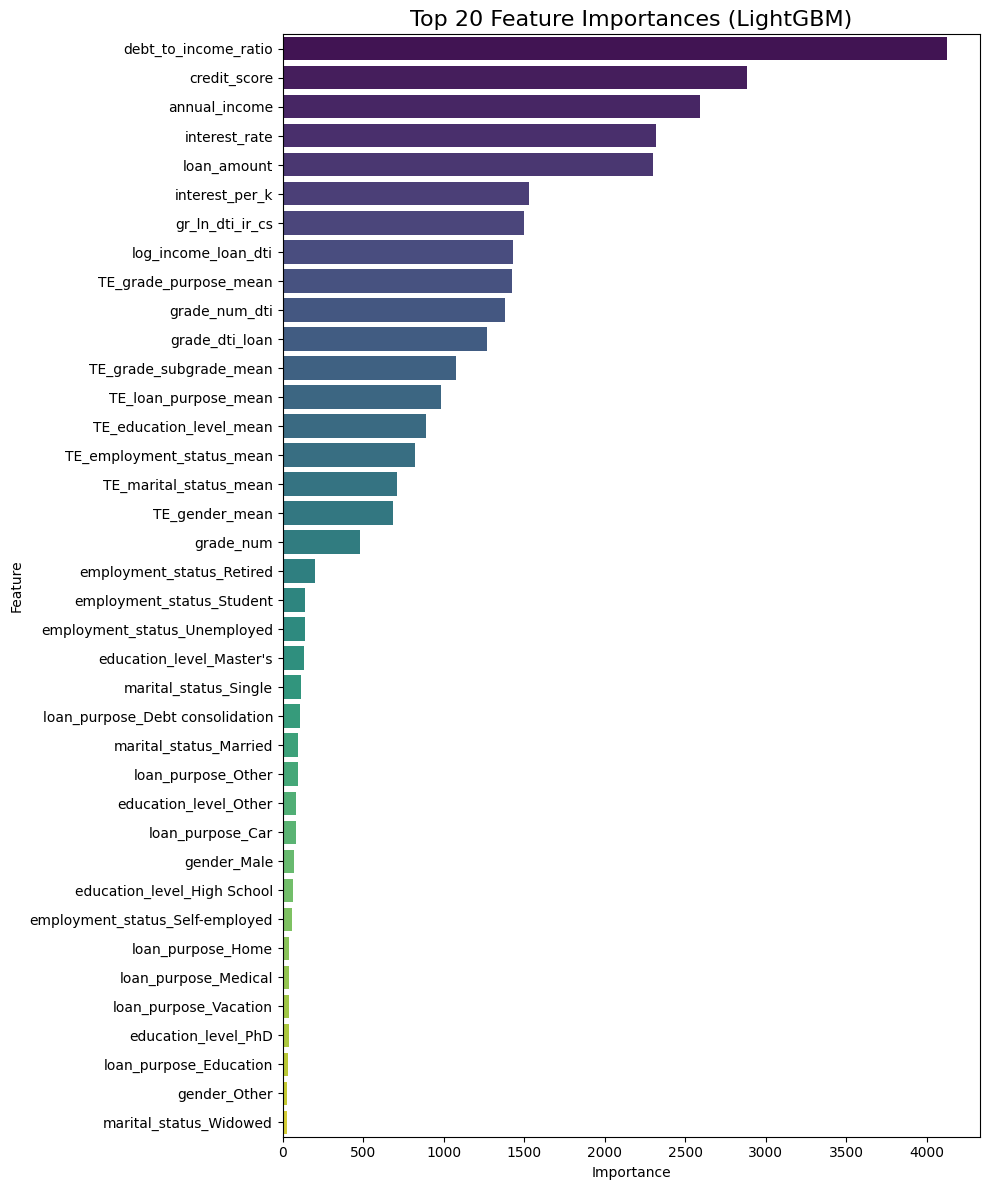


=== Summary of Experiments ===

              Timestamp  ROC-AUC Score
0   2025-11-30 18:05:48        0.92156
1   2025-11-30 16:47:59        0.92138
2   2025-11-30 17:57:42        0.92135
3   2025-11-30 17:35:32        0.92130
4   2025-11-30 17:32:34        0.92130
5   2025-11-30 17:28:33        0.92123
6   2025-11-30 17:14:20        0.91906
7   2025-11-30 16:30:19        0.91905
8   2025-11-30 16:20:28        0.91899
9   2025-11-30 16:17:34        0.91881
10  2025-11-30 16:58:52        0.91870
11  2025-11-30 15:08:15        0.91859
12  2025-11-30 15:45:56        0.91838
13  2025-11-30 15:41:54        0.91838


In [122]:
dev_input = "crete ohe without grade_subgrade and grade_purpose"

X, y, X_res, X_id,  = preprocessed_pipe(add_cols=['grade_purpose'], to_encoding=True, drop_original=True)
model_training(
    X = X, 
    y = y,
    X_res = X_res,
    X_id = X_id,
    lgbm_params= lgbm_params,
    dev_input = dev_input
)
# Example usage:
summary_df = summarize_experiment_logs()
print("\n=== Summary of Experiments ===\n")
print(summary_df)


In [106]:
X, y, X_res, X_id,  = preprocessed_pipe(add_cols=['grade_purpose'], to_encoding=True, drop_original=True)


Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'gender', 'marital_status', 'education_level',
       'employment_status', 'loan_purpose', 'grade_subgrade', 'grade_num',
       'grade_num_dti', 'grade_dti_loan', 'gr_ln_dti_ir_cs', 'grade_purpose',
       'interest_per_k', 'log_income_loan_dti'],
      dtype='object')
Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'grade_num', 'grade_num_dti', 'grade_dti_loan',
       'gr_ln_dti_ir_cs', 'interest_per_k', 'log_income_loan_dti',
       'TE_gender_mean', 'TE_marital_status_mean', 'TE_education_level_mean',
       'TE_employment_status_mean', 'TE_loan_purpose_mean',
       'TE_grade_subgrade_mean', 'TE_grade_purpose_mean'],
      dtype='object')


C:\Users\16yas\AppData\Local\Temp\ipykernel_52508\149430301.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\16yas\AppData\Local\Temp\ipykernel_52508\149430301.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [107]:
X.dtypes

annual_income                float64
debt_to_income_ratio         float64
credit_score                   int64
loan_amount                  float64
interest_rate                float64
grade_num                      int64
grade_num_dti                float64
grade_dti_loan               float64
gr_ln_dti_ir_cs              float64
interest_per_k               float64
log_income_loan_dti          float64
TE_gender_mean               float64
TE_marital_status_mean       float64
TE_education_level_mean      float64
TE_employment_status_mean    float64
TE_loan_purpose_mean         float64
TE_grade_subgrade_mean       float64
TE_grade_purpose_mean        float64
dtype: object

In [109]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import LabelEncoder


def analyze_feature_target_relationship(X, y):
    """
    Analyze the relationship between each feature and a binary classification target.
    Works for both numeric and categorical columns.

    Returns:
        dict containing:
            - point_biserial_df
            - mi_numeric_df
            - chi_square_df
            - mi_categorical_df
            - combined_ranking_df
    """

    # Separate columns
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    results = {}

    # =====================
    # 1. Point-Biserial (Numeric ↔ Target)
    # =====================
    pb_results = {}
    for col in num_cols:
        corr, p_value = pointbiserialr(X[col], y)
        pb_results[col] = {"corr": corr, "p_value": p_value}

    point_biserial_df = pd.DataFrame(pb_results).T.sort_values("corr", ascending=False)
    results["point_biserial_df"] = point_biserial_df

    # =====================
    # 2. Mutual Information (Numeric)
    # =====================
    if len(num_cols) > 0:
        mi_numeric = mutual_info_classif(X[num_cols], y)
        mi_numeric_df = pd.DataFrame({
            "feature": num_cols,
            "mutual_info": mi_numeric
        }).sort_values("mutual_info", ascending=False)
    else:
        mi_numeric_df = pd.DataFrame()
    results["mi_numeric_df"] = mi_numeric_df

    # =====================
    # 3. Chi-square Test (Categorical)
    # =====================
    if len(cat_cols) > 0:
        X_cat_encoded = X[cat_cols].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
        chi_scores, p_vals = chi2(X_cat_encoded, y)

        chi_square_df = pd.DataFrame({
            "feature": cat_cols,
            "chi_square": chi_scores,
            "p_value": p_vals
        }).sort_values("chi_square", ascending=False)
    else:
        chi_square_df = pd.DataFrame()
    results["chi_square_df"] = chi_square_df

    # =====================
    # 4. Mutual Information (Categorical)
    # =====================
    if len(cat_cols) > 0:
        mi_cat = mutual_info_classif(X_cat_encoded, y)
        mi_categorical_df = pd.DataFrame({
            "feature": cat_cols,
            "mutual_info": mi_cat
        }).sort_values("mutual_info", ascending=False)
    else:
        mi_categorical_df = pd.DataFrame()
    results["mi_categorical_df"] = mi_categorical_df

    # =====================
    # 5. Combined Ranking
    # =====================
    combined = []

    # Add point biserial
    for feature, row in point_biserial_df.iterrows():
        combined.append([feature, abs(row["corr"]), "point_biserial"])

    # Add MI numeric
    for _, row in mi_numeric_df.iterrows():
        combined.append([row["feature"], row["mutual_info"], "mi_numeric"])

    # Add chi-square
    for _, row in chi_square_df.iterrows():
        combined.append([row["feature"], row["chi_square"], "chi_square"])

    # Add MI categorical
    for _, row in mi_categorical_df.iterrows():
        combined.append([row["feature"], row["mutual_info"], "mi_categorical"])

    combined_df = pd.DataFrame(combined, columns=["feature", "score", "method"])
    combined_ranking_df = combined_df.sort_values("score", ascending=False).reset_index(drop=True)

    results["combined_ranking_df"] = combined_ranking_df

    return results
results = analyze_feature_target_relationship(X, y)

print("=== Point-Biserial (Numeric) ===")
display(results["point_biserial_df"])

print("=== Mutual Information (Numeric) ===")
display(results["mi_numeric_df"])

print("=== Chi-Square (Categorical) ===")
display(results["chi_square_df"])

print("=== Mutual Information (Categorical) ===")
display(results["mi_categorical_df"])

print("=== Combined Ranking ===")
display(results["combined_ranking_df"])


=== Point-Biserial (Numeric) ===


,corr,p_value
TE_employment_status_mean,0.656815,0.000000e+00
credit_score,0.234560,0.000000e+00
TE_grade_purpose_mean,0.228314,0.000000e+00
TE_grade_subgrade_mean,0.227726,0.000000e+00
TE_education_level_mean,0.025051,4.417089e-83
TE_loan_purpose_mean,0.024726,5.457052e-81
TE_gender_mean,0.006346,1.001784e-06
annual_income,0.006326,1.086521e-06
TE_marital_status_mean,-0.002346,7.063748e-02
loan_amount,-0.003762,3.736888e-03


=== Mutual Information (Numeric) ===


,feature,mutual_info
14,TE_employment_status_mean,0.187513
6,grade_num_dti,0.088969
1,debt_to_income_ratio,0.079917
7,grade_dti_loan,0.072565
8,gr_ln_dti_ir_cs,0.067035
10,log_income_loan_dti,0.053310
2,credit_score,0.034355
5,grade_num,0.033385
16,TE_grade_subgrade_mean,0.027917
17,TE_grade_purpose_mean,0.027813


=== Chi-Square (Categorical) ===


""


=== Mutual Information (Categorical) ===


""


=== Combined Ranking ===


,feature,score,method
0,TE_employment_status_mean,0.656815,point_biserial
1,grade_num_dti,0.382053,point_biserial
2,grade_dti_loan,0.379728,point_biserial
3,gr_ln_dti_ir_cs,0.372059,point_biserial
4,debt_to_income_ratio,0.335680,point_biserial
5,log_income_loan_dti,0.330507,point_biserial
6,credit_score,0.234560,point_biserial
7,TE_grade_purpose_mean,0.228314,point_biserial
8,TE_grade_subgrade_mean,0.227726,point_biserial
9,grade_num,0.212376,point_biserial


In [111]:
scale_pos_weight

np.float64(0.25184723094496453)

In [127]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
import numpy as np
import optuna

X, y, X_res, X_id,  = preprocessed_pipe(add_cols=['grade_purpose'], to_encoding=True, drop_original=True)


def optuna_lgbm_objective(trial, X, y, monotone_constraints=None):

    params = {
        "objective": "binary",
        "metric": "auc",

        "verbose": -1,
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.09, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 150),
        "min_split_gain": trial.suggest_float("min_split_gain", 0, 1),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 50, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 1000, 12000),
        "n_jobs": 14
    }

    if monotone_constraints is not None:
        params["monotone_constraints"] = monotone_constraints

    # Stratified 5-fold CV
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for fold, (tr, val) in enumerate(kf.split(X, y)):
        Xtr, Xval = X.iloc[tr], X.iloc[val]
        ytr, yval = y.iloc[tr], y.iloc[val]

        dtrain = lgb.Dataset(Xtr, ytr)
        dvalid = lgb.Dataset(Xval, yval)

        callbacks = [
            lgb.early_stopping(stopping_rounds=200, verbose=False),
            lgb.log_evaluation(period=0),
            # optuna.integration.LightGBMPruningCallback(trial, "auc")
        ]

        model = lgb.train(
            params,
            dtrain,
            valid_sets=[dtrain, dvalid],
            callbacks=callbacks
        )

        preds = model.predict(Xval)
        aucs.append(roc_auc_score(yval, preds))

    return np.mean(aucs)

def run_optuna(X, y, monotone_constraints=None, n_trials=50):

    study = optuna.create_study(
        direction="maximize",
        study_name="lgbm_opt",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner()
    )

    study.optimize(
        lambda trial: optuna_lgbm_objective(
            trial=trial, 
            X=X, 
            y=y, 
            monotone_constraints=monotone_constraints
        ),
        n_trials=n_trials,
        show_progress_bar=True
    )

    return study
monotone_constraints = [1, 0, 0, -1]

study = run_optuna(X, y)


C:\Users\16yas\AppData\Local\Temp\ipykernel_52508\149430301.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\16yas\AppData\Local\Temp\ipykernel_52508\149430301.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'grade_subgrade', 'grade_num', 'grade_num_dti',
       'grade_dti_loan', 'gr_ln_dti_ir_cs', 'grade_purpose', 'interest_per_k',
       'gender_Male', 'gender_Other', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_High School', 'education_level_Master's',
       'education_level_Other', 'education_level_PhD',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'loan_purpose_Car', 'loan_purpose_Debt consolidation',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical',
       'loan_purpose_Other', 'loan_purpose_Vacation', 'gender',
       'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'log_income_loan_dti'],
      dtype='object')
Index(['annual_income', 'debt_to_income_ratio', 'c

Best trial: 0. Best value: 0.921041:   2%|▏         | 1/50 [05:44<4:41:01, 344.11s/it]

[I 2025-11-30 18:40:48,382] Trial 0 finished with value: 0.9210409472249503 and parameters: {'learning_rate': 0.014761140622734634, 'num_leaves': 245, 'min_child_samples': 111, 'min_split_gain': 0.5986584841970366, 'reg_alpha': 1.5601864044243652, 'reg_lambda': 1.5599452033620265, 'subsample': 0.6232334448672797, 'colsample_bytree': 0.9464704583099741, 'max_depth': 7, 'min_child_weight': 2.124280213720889, 'n_estimators': 1226}. Best is trial 0 with value: 0.9210409472249503.


Best trial: 1. Best value: 0.922994:   4%|▍         | 2/50 [14:12<5:52:31, 440.65s/it]

...

Best trial: 23. Best value: 0.923354:  80%|████████  | 40/50 [16:32:12<28:34:20, 10286.10s/it]

[I 2025-12-01 11:07:16,652] Trial 39 finished with value: 0.9216263125485046 and parameters: {'learning_rate': 0.04613274352662457, 'num_leaves': 224, 'min_child_samples': 112, 'min_split_gain': 0.34256733306649945, 'reg_alpha': 3.7040569834297217, 'reg_lambda': 1.8427303847773788, 'subsample': 0.7651253469194265, 'colsample_bytree': 0.9591038766740505, 'max_depth': 0, 'min_child_weight': 0.0014729387536384522, 'n_estimators': 9079}. Best is trial 23 with value: 0.9233544761452602.


Best trial: 23. Best value: 0.923354:  80%|████████  | 40/50 [16:44:30<4:11:07, 1506.77s/it]  


[W 2025-12-01 11:19:34,116] Trial 40 failed with parameters: {'learning_rate': 0.005153865038347197, 'num_leaves': 56, 'min_child_samples': 79, 'min_split_gain': 0.9927990587395406, 'reg_alpha': 8.267571448364682, 'reg_lambda': 2.41902681646218, 'subsample': 0.8107577425584085, 'colsample_bytree': 0.9160262439794525, 'max_depth': 3, 'min_child_weight': 0.003178243488501462, 'n_estimators': 11198} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "d:\Dsoft\Projects\ML\.venv\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\16yas\AppData\Local\Temp\ipykernel_52508\2877937680.py", line 73, in <lambda>
    lambda trial: optuna_lgbm_objective(
                  ~~~~~~~~~~~~~~~~~~~~~^
        trial=trial,
        ^^^^^^^^^^^^
    ...<2 lines>...
        monotone_constraints=monotone_constraints
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ),
    ^
  File "C:\Users\16ya

KeyboardInterrupt: 